# 02 — GTFS schedule exploration

MTS + NCTD **static GTFS** coverage: entity counts, service calendar, stops vs study **bbox**, trip volumes per route, and a **weekday headway proxy** from first-stop departure spacing (feeds tract-level service summaries in `04_spatial_alignment_and_coverage.ipynb`).

**Prior:** [`01_inventory_and_provenance.ipynb`](01_inventory_and_provenance.ipynb)  
**Next:** [`03_census_tracts_and_acs.ipynb`](03_census_tracts_and_acs.ipynb)


In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")


def find_repo_root() -> Path:
    start = Path.cwd().resolve()
    for d in [start, *start.parents]:
        if (d / "configs" / "san_diego.yaml").exists():
            return d
    raise FileNotFoundError("Could not find configs/san_diego.yaml (cd to repo root).")


REPO_ROOT = find_repo_root()

with open(REPO_ROOT / "configs" / "defaults.yaml") as f:
    config = yaml.safe_load(f)
with open(REPO_ROOT / "configs" / "san_diego.yaml") as f:
    config.update(yaml.safe_load(f))

bbox = config["bbox"]  # [min_lon, min_lat, max_lon, max_lat]
min_lon, min_lat, max_lon, max_lat = bbox
agencies_cfg = config.get("gtfs_agencies", [])
print(f"REPO_ROOT={REPO_ROOT}")
print(f"bbox={bbox}")


REPO_ROOT=C:\Users\sardo\OneDrive\Desktop\Classes\Projects\BayesTransitEquity
bbox=[-117.28, 32.53, -116.93, 33.11]


In [2]:
GTFS_TABLES = (
    "agency",
    "routes",
    "trips",
    "stops",
    "stop_times",
    "calendar",
    "calendar_dates",
    "shapes",
)


def load_gtfs_feed(extracted_dir: Path) -> dict[str, pd.DataFrame | None]:
    """Load standard GTFS .txt tables from an extracted feed directory."""
    out: dict[str, pd.DataFrame | None] = {}
    for name in GTFS_TABLES:
        p = extracted_dir / f"{name}.txt"
        if not p.exists():
            out[name] = None
            continue
        out[name] = pd.read_csv(p, encoding="utf-8", low_memory=False)
    return out


feeds: dict[str, dict[str, pd.DataFrame | None]] = {}
for ag in agencies_cfg:
    aid = ag["id"]
    raw = REPO_ROOT / ag["raw_path"]
    ex = raw / "extracted"
    if not ex.is_dir():
        raise FileNotFoundError(f"Missing extracted GTFS for {aid}: {ex}")
    feeds[aid] = load_gtfs_feed(ex)
    print(f"Loaded {aid}: {ex.relative_to(REPO_ROOT)}")


Loaded mts: data\raw\gtfs\mts\extracted


Loaded nctd: data\raw\gtfs\nctd\extracted


## Summary counts


In [3]:
rows = []
for aid, F in feeds.items():
    r, t, s, st = F["routes"], F["trips"], F["stops"], F["stop_times"]
    cal, cd, sh = F["calendar"], F["calendar_dates"], F["shapes"]
    rows.append(
        {
            "agency": aid,
            "routes": len(r) if r is not None else 0,
            "trips": len(t) if t is not None else 0,
            "stops": len(s) if s is not None else 0,
            "stop_times_rows": len(st) if st is not None else 0,
            "calendar_rows": len(cal) if cal is not None else 0,
            "calendar_dates_rows": len(cd) if cd is not None else 0,
            "shapes_rows": len(sh) if sh is not None else 0,
        }
    )
summary = pd.DataFrame(rows)
display(Markdown("### Feed size summary"))
display(summary)


### Feed size summary

,agency,routes,trips,stops,stop_times_rows,calendar_rows,calendar_dates_rows,shapes_rows
0,mts,105,22705,4373,671017,44,111,97051
1,nctd,50,4589,1823,157825,30,14,36993


## Spatial coverage vs bbox


In [4]:
def stops_in_bbox(stops: pd.DataFrame) -> pd.Series:
    lat, lon = stops["stop_lat"].astype(float), stops["stop_lon"].astype(float)
    return (lon >= min_lon) & (lon <= max_lon) & (lat >= min_lat) & (lat <= max_lat)


bbox_rows = []
stop_points = []
for aid, F in feeds.items():
    s = F["stops"]
    if s is None or s.empty:
        continue
    inside = stops_in_bbox(s)
    bbox_rows.append(
        {
            "agency": aid,
            "n_stops": len(s),
            "n_in_bbox": int(inside.sum()),
            "pct_in_bbox": round(100 * inside.mean(), 2),
        }
    )
    tmp = s.loc[inside, ["stop_lat", "stop_lon"]].copy()
    tmp["agency"] = aid
    stop_points.append(tmp)
display(Markdown("### Stops vs study bbox (`configs/san_diego.yaml`)"))
display(pd.DataFrame(bbox_rows))

stops_plot_df = pd.concat(stop_points, ignore_index=True) if stop_points else pd.DataFrame()


### Stops vs study bbox (`configs/san_diego.yaml`)

,agency,n_stops,n_in_bbox,pct_in_bbox
0,mts,4373,4085,93.41
1,nctd,1823,342,18.76


Saved: artifacts\figures\eda__gtfs_stops_map__2026-03-29.png


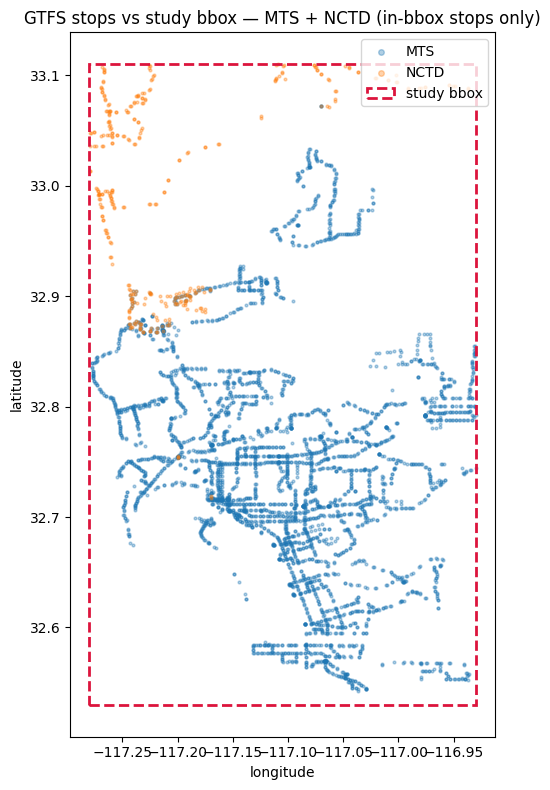

In [5]:
if not stops_plot_df.empty:
    from datetime import date as _date
    fig, ax = plt.subplots(figsize=(8, 8))
    colors = {"mts": "#1f77b4", "nctd": "#ff7f0e"}
    for aid, g in stops_plot_df.groupby("agency"):
        ax.scatter(
            g["stop_lon"],
            g["stop_lat"],
            s=4,
            alpha=0.35,
            label=aid.upper(),
            c=colors.get(aid, "gray"),
        )
    rect = plt.Rectangle(
        (min_lon, min_lat),
        max_lon - min_lon,
        max_lat - min_lat,
        fill=False,
        edgecolor="crimson",
        linewidth=2,
        linestyle="--",
        label="study bbox",
    )
    ax.add_patch(rect)
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    ax.set_title("GTFS stops vs study bbox — MTS + NCTD (in-bbox stops only)")
    ax.legend(loc="upper right", markerscale=2)
    ax.set_aspect("equal", adjustable="box")
    plt.tight_layout()

    # ── Save figure ───────────────────────────────────────────────────────────
    ART_FIG = REPO_ROOT / "artifacts" / "figures"
    ART_FIG.mkdir(parents=True, exist_ok=True)
    _fig_path = ART_FIG / f"eda__gtfs_stops_map__{_date.today().isoformat()}.png"
    fig.savefig(_fig_path, dpi=200, bbox_inches="tight")
    print(f"Saved: {_fig_path.relative_to(REPO_ROOT)}")

    plt.show()
else:
    display(Markdown("_No stops to plot._"))

## Calendar and weekday trip intensity


In [6]:
def weekday_service_ids(calendar: pd.DataFrame | None) -> set:
    if calendar is None or calendar.empty or "monday" not in calendar.columns:
        return set()
    m = calendar["monday"].astype(str).str.strip() == "1"
    return set(calendar.loc[m, "service_id"].astype(str))


cal_rows = []
for aid, F in feeds.items():
    cal = F["calendar"]
    if cal is None:
        continue
    w = weekday_service_ids(cal)
    cal_rows.append(
        {
            "agency": aid,
            "n_service_ids": cal["service_id"].nunique(),
            "n_weekday_service_ids": len(w),
            "date_range_sample": f"{cal['start_date'].min()} – {cal['end_date'].max()}",
        }
    )
display(Markdown("### Calendar (weekday = Monday flag `monday==1`)"))
display(pd.DataFrame(cal_rows))


### Calendar (weekday = Monday flag `monday==1`)

,agency,n_service_ids,n_weekday_service_ids,date_range_sample
0,mts,44,29,20260125 – 20260606
1,nctd,30,16,20250205 – 20250517


In [7]:
def trips_per_route(trips: pd.DataFrame, routes: pd.DataFrame, weekday_ids: set) -> pd.DataFrame:
    t = trips.copy()
    if weekday_ids:
        t = t[t["service_id"].astype(str).isin(weekday_ids)]
    c = t.groupby("route_id", as_index=False).size().rename(columns={"size": "n_trips"})
    r = routes.copy()
    r["route_id"] = r["route_id"].astype(str)
    c["route_id"] = c["route_id"].astype(str)
    name_col = "route_short_name" if "route_short_name" in r.columns else None
    if name_col:
        rnm = r[["route_id", name_col]].drop_duplicates("route_id")
        c = c.merge(rnm, on="route_id", how="left")
    return c.sort_values("n_trips", ascending=False)


display(Markdown("### Top routes by **weekday** trip count (`monday==1` services)"))
for aid, F in feeds.items():
    t, r, cal = F["trips"], F["routes"], F["calendar"]
    if t is None or r is None:
        continue
    wids = weekday_service_ids(cal)
    pr = trips_per_route(t, r, wids)
    display(Markdown(f"#### {aid.upper()}"))
    display(pr.head(15).reset_index(drop=True))


### Top routes by **weekday** trip count (`monday==1` services)

#### MTS

,route_id,n_trips,route_short_name
0,227,472,227
1,215,444,215
2,7,438,7
3,929,309,929
4,13,309,13
5,12,308,12
6,8,297,8
7,510,295,Blue
8,3,282,3
9,30,278,30


#### NCTD

,route_id,n_trips,route_short_name
0,350,231,350.0
1,303,204,303.0
2,302,202,302.0
3,332,172,332.0
4,305,149,305.0
5,399,136,NaN
6,301,126,101.0
7,309,122,309.0
8,354,122,354.0
9,347,112,347.0


## Headway proxy (first-stop departures, weekday)


In [8]:
def departure_to_seconds(x) -> float:
    if pd.isna(x):
        return np.nan
    parts = str(x).strip().split(":")
    if len(parts) != 3:
        return np.nan
    h, m, s = int(parts[0]), int(parts[1]), float(parts[2])
    return h * 3600 + m * 60 + s


def median_headway_first_stop(
    trips: pd.DataFrame,
    stop_times: pd.DataFrame,
    weekday_ids: set,
    min_gap_s: float = 120.0,
    max_gap_s: float = 10800.0,
) -> pd.DataFrame:
    """Median spacing between consecutive first-stop departures by route and direction (weekday trips)."""
    if trips is None or stop_times is None or not weekday_ids:
        return pd.DataFrame()
    t = trips[trips["service_id"].astype(str).isin(weekday_ids)].copy()
    st = stop_times.merge(t[["trip_id", "route_id", "direction_id"]], on="trip_id", how="inner")
    st = st[st["stop_sequence"].astype(int) == 1].copy()
    st["dep_s"] = st["departure_time"].map(departure_to_seconds)
    st = st.dropna(subset=["dep_s"])
    rows = []
    for (rid, did), g in st.groupby(["route_id", "direction_id"]):
        srt = np.sort(g["dep_s"].values)
        if len(srt) < 2:
            continue
        gaps = np.diff(srt)
        gaps = gaps[(gaps >= min_gap_s) & (gaps <= max_gap_s)]
        if len(gaps) == 0:
            continue
        rows.append(
            {
                "route_id": rid,
                "direction_id": did,
                "median_headway_min": float(np.median(gaps) / 60.0),
                "n_gaps": len(gaps),
            }
        )
    return pd.DataFrame(rows)


display(
    Markdown(
        "### Weekday headway proxy (first `stop_sequence==1`, gaps "
        f"{120}s–{10800}s between consecutive departures)"
    )
)
for aid, F in feeds.items():
    t, st, cal = F["trips"], F["stop_times"], F["calendar"]
    wids = weekday_service_ids(cal)
    hw = median_headway_first_stop(t, st, wids)
    if hw.empty:
        display(Markdown(f"_{aid}: no headway estimates._"))
        continue
    hw = hw.sort_values("median_headway_min")
    display(Markdown(f"#### {aid.upper()} — shortest median headway (top 10)"))
    display(hw.head(10).reset_index(drop=True))
    display(Markdown(f"#### {aid.upper()} — longest median headway (bottom 10)"))
    display(hw.tail(10).reset_index(drop=True))


### Weekday headway proxy (first `stop_sequence==1`, gaps 120s–10800s between consecutive departures)

#### MTS — shortest median headway (top 10)

,route_id,direction_id,median_headway_min,n_gaps
0,201,1,5.0,154
1,12,1,7.0,115
2,13,1,7.0,128
3,13,0,7.0,116
4,932,1,7.0,106
5,12,0,8.0,115
6,709,0,8.0,100
7,3,1,8.0,107
8,934,0,8.0,112
9,955,0,8.0,114


#### MTS — longest median headway (bottom 10)

,route_id,direction_id,median_headway_min,n_gaps
0,838,0,60.0,14
1,834,0,60.0,12
2,967,1,60.0,14
3,909,0,60.0,14
4,904,1,60.0,8
5,909,1,60.5,14
6,968,1,65.0,15
7,968,0,66.0,14
8,83,0,70.0,10
9,83,1,70.0,10


#### NCTD — shortest median headway (top 10)

,route_id,direction_id,median_headway_min,n_gaps
0,302,1,20.0,50
1,302,0,20.0,49
2,303,1,20.0,47
3,303,0,20.0,53
4,332,1,20.0,41
5,332,0,20.0,43
6,350,1,20.0,57
7,350,0,20.0,58
8,352,0,20.0,46
9,351,1,20.0,47


#### NCTD — longest median headway (bottom 10)

,route_id,direction_id,median_headway_min,n_gaps
0,371,1,107.0,4
1,371,0,110.0,3
2,388,1,118.0,9
3,358,0,120.0,7
4,359,1,120.0,7
5,388,0,120.0,9
6,604,1,126.0,1
7,623,0,139.0,1
8,395,0,175.0,1
9,395,1,180.0,1


## Sanity checks


In [9]:
def data_quality(feed: dict[str, pd.DataFrame | None], aid: str) -> pd.DataFrame:
    routes, trips, stops, st = feed["routes"], feed["trips"], feed["stops"], feed["stop_times"]
    issues = []
    if routes is not None and trips is not None:
        rids = set(routes["route_id"].astype(str))
        tids = trips["route_id"].astype(str).unique()
        orphan_tr = set(tids) - rids
        issues.append({"agency": aid, "check": "trips referencing unknown route_id", "count": len(orphan_tr)})
        tr_per_r = trips.groupby("route_id").size()
        zero = set(routes["route_id"].astype(str)) - set(tr_per_r.index.astype(str))
        issues.append({"agency": aid, "check": "routes with zero trips", "count": len(zero)})
    if stops is not None and st is not None:
        used = set(st["stop_id"].astype(str).unique())
        alls = set(stops["stop_id"].astype(str))
        issues.append({"agency": aid, "check": "stops never used in stop_times", "count": len(alls - used)})
    return pd.DataFrame(issues)


dq = pd.concat([data_quality(feeds[a], a) for a in feeds], ignore_index=True)
display(Markdown("### Data quality flags (counts)"))
display(dq)


### Data quality flags (counts)

,agency,check,count
0,mts,trips referencing unknown route_id,0
1,mts,routes with zero trips,0
2,mts,stops never used in stop_times,106
3,nctd,trips referencing unknown route_id,0
4,nctd,routes with zero trips,3
5,nctd,stops never used in stop_times,12


## Export artifacts

Tables exported to `artifacts/tables/` and figure already saved above.
Naming convention: `eda__<description>__<YYYY-MM-DD>.csv`

In [10]:
from datetime import date as _date

TODAY = _date.today().isoformat()
ART_TABLES = REPO_ROOT / "artifacts" / "tables"
ART_TABLES.mkdir(parents=True, exist_ok=True)

exported = []

# ── Feed size summary ─────────────────────────────────────────────────────────
p = ART_TABLES / f"eda__gtfs_feed_summary__{TODAY}.csv"
summary.to_csv(p, index=False)
exported.append(str(p.relative_to(REPO_ROOT)))

# ── Bbox stop coverage ────────────────────────────────────────────────────────
bbox_cov_df = pd.DataFrame(bbox_rows)
p = ART_TABLES / f"eda__gtfs_bbox_coverage__{TODAY}.csv"
bbox_cov_df.to_csv(p, index=False)
exported.append(str(p.relative_to(REPO_ROOT)))

# ── Calendar summary ──────────────────────────────────────────────────────────
cal_df = pd.DataFrame(cal_rows)
p = ART_TABLES / f"eda__gtfs_calendar__{TODAY}.csv"
cal_df.to_csv(p, index=False)
exported.append(str(p.relative_to(REPO_ROOT)))

# ── Headways (all agencies combined) ─────────────────────────────────────────
hw_frames = []
for aid, F in feeds.items():
    t, st, cal = F["trips"], F["stop_times"], F["calendar"]
    wids = weekday_service_ids(cal)
    hw = median_headway_first_stop(t, st, wids)
    if not hw.empty:
        hw.insert(0, "agency", aid)
        hw_frames.append(hw)

if hw_frames:
    hw_all = pd.concat(hw_frames, ignore_index=True).sort_values(
        ["agency", "median_headway_min"]
    )
    p = ART_TABLES / f"eda__gtfs_headways__{TODAY}.csv"
    hw_all.to_csv(p, index=False)
    exported.append(str(p.relative_to(REPO_ROOT)))

# ── Data quality flags ────────────────────────────────────────────────────────
p = ART_TABLES / f"eda__gtfs_data_quality__{TODAY}.csv"
dq.to_csv(p, index=False)
exported.append(str(p.relative_to(REPO_ROOT)))

display(Markdown("### Exported"))
for e in exported:
    display(Markdown(f"- `{e}`"))
print(f"\n{len(exported)} table(s) written to artifacts/tables/")
print("Figure already saved to artifacts/figures/ (see stops map cell above)")

### Exported

- `artifacts\tables\eda__gtfs_feed_summary__2026-03-29.csv`

- `artifacts\tables\eda__gtfs_bbox_coverage__2026-03-29.csv`

- `artifacts\tables\eda__gtfs_calendar__2026-03-29.csv`

- `artifacts\tables\eda__gtfs_headways__2026-03-29.csv`

- `artifacts\tables\eda__gtfs_data_quality__2026-03-29.csv`


5 table(s) written to artifacts/tables/
Figure already saved to artifacts/figures/ (see stops map cell above)
